1. data (prepare and load) -- Dataset, DataLoader,torchvision.transform
2. build model -- torch.nn.Module, torchvision.models, torch.optim (optimizer)
3. fitting the model with data (training)
4. making predictions and evaluating a model (inference) -- torchmetrics
5. improve through experimentation -- tensorboard
6. saving and loading a model

In [65]:
# checking the contents of our PyTorch model - what is inside?
# check .parameters()

import torch
import torch.nn as nn

In [66]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weight * x + self.bias

In [67]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
model_0

LinearRegressionModel()

In [68]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [69]:
# list named parameters
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [70]:
 # what we expect, the ideal values: weight = 0.7, bias = 0.3
# usually we don't know them

### making prediction using `torch.inference_mode()`

to see our model's prediction power, let's see how well it predicts `y_test` based on `X_test`.

When we pass data through our model, it's going to run it through the `forward()` method.

In [71]:
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
weight = 0.7
bias = 0.3
y = weight * X + bias
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [72]:
# make prediction with model

with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [73]:
from matplotlib import pyplot as plt


def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    # plot training data in blue
    plt.scatter(train_data, train_labels, s=4, color='b', label='Training data')
    # plot training data in green
    plt.scatter(test_data, test_labels, s=4, color='y', label='Testing data')
    # are there predictions?
    if predictions is not None:
        plt.scatter(test_data, predictions, s=4, color='r', label='Predictions')

    # show the legend
    plt.legend(prop={'size': 14})

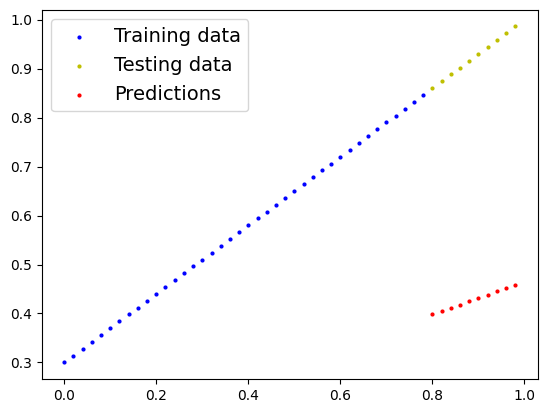

In [74]:
 # random values
plot_predictions(predictions=y_preds)
y_preds = model_0(X_test)

```
with torch.inference_mode():
    y_preds = model_0(X_test)
```

This is a context manager.

In [75]:
# without context manager: we have an inference tracking.
# (context manager turns off the inference. when we don't do training,
# we don't need to keep track of gradient, how to update the model)

# the benefit to use context manager: keep track of less data

y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

# Train model

The idea of training is for a model to move from unknown parameters (random values) to some known parameters.

Things we need to train:

- One way to measure is to use **loss function** (= cost function, criterion). Measure, how wrong your model's predictions to the ideal outputs. Lower is better.

https://docs.pytorch.org/docs/stable/nn.html#loss-functions

- **Optimizer**: takes into account the loss of a model and adjusts the model's parameters.

And specifically for PyTorch, we need:
- a training loop
- a testing loop


In [76]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [77]:
# setup a loss function (l1loss = MAE)
# MAE = Mean Absolute Error, repeat for all and take the mean (average)
# how wrong is the model
loss_fn = nn.L1Loss()

# setup an optimizer (stochastic gradient descent) = starts by randomly adjusting values,
# then going towards where loss can be minimized
# talks to the loss function, adjust parameters to reduce the loss
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)
# lr = learning rate, most important hyperparameter

### Building a training and testing loop

What we need in a training loop:

1. Loop through a data and do...
2. Forward pass / forward propagation (this involves data moving through our model's `forward()` method
3. Calculate the loss (compare forward pass predictions to ground truth labels)
4. Optimizer zero grad
5. Loss backward = move backward through the network to calculate the gradients of each of the parameters with respect to the loss (**backpropagation**)
6. Optimizer step = use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [78]:
print(list(model_0.parameters()))

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [87]:
# an epoch is one loop through the data
torch.manual_seed(42)
epochs = 200

# tracking experience/progress
epoch_count = []
loss_values = []
test_loss_values = []

# --- Training ---

# 1. loop through the data
for epoch in range(epochs):
    # set the model to training mode = sets requires_grad=True
    model_0.train()

    # 2. forward pass, pass the data through the model (with forward())
    # this is where the model learns patter on the data
    y_pred = model_0(X_train)

    # 3. calculate loss (input, target) - we calculate the difference between our model's predictions
    # on the training dataset and on the ideal values
    loss = loss_fn(y_pred, y_train)
    # + check: learning rate scheduling , convergence

    # 4. optimizer zero grad
    optimizer.zero_grad()

    # 5. perform backpropagation on the loss with respect to the parameters of the model
    loss.backward()

    # 6.step the optimizer (perform gradient descent)
    optimizer.step()
    # by default how the optimizer changes will accumulate through the loop
    # so... we have to zero them above in step 4 for the next iteration of the loop

    # --- Testing ---

    # turns off gradient descent/tracking and settings what not needed for evaluation/testing
    # (dropout, batchnorm)
    model_0.eval()

    # turns off gradient tracking & couple more things behind the scenes
    with torch.inference_mode():
        # 1. do the forward pass in inference mode
        test_pred = model_0(X_test)
        # 2. calculate the test loss
        test_loss = loss_fn(test_pred, y_test)

    # print out what's happening
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)

        print('epoch:', epoch, ', loss:', loss, ', test_loss:', test_loss)
        # print out model state dict
        print(model_0.state_dict(), "\n")


epoch: 0 , loss: tensor(0.0764, grad_fn=<MeanBackward0>) , test_loss: tensor(0.1977)
OrderedDict({'weight': tensor([0.4258]), 'bias': tensor([0.3463])}) 

epoch: 10 , loss: tensor(0.0507, grad_fn=<MeanBackward0>) , test_loss: tensor(0.1365)
OrderedDict({'weight': tensor([0.4564]), 'bias': tensor([0.3803])}) 

epoch: 20 , loss: tensor(0.0446, grad_fn=<MeanBackward0>) , test_loss: tensor(0.1100)
OrderedDict({'weight': tensor([0.4788]), 'bias': tensor([0.3868])}) 

epoch: 30 , loss: tensor(0.0410, grad_fn=<MeanBackward0>) , test_loss: tensor(0.0970)
OrderedDict({'weight': tensor([0.4974]), 'bias': tensor([0.3833])}) 

epoch: 40 , loss: tensor(0.0375, grad_fn=<MeanBackward0>) , test_loss: tensor(0.0867)
OrderedDict({'weight': tensor([0.5152]), 'bias': tensor([0.3778])}) 

epoch: 50 , loss: tensor(0.0341, grad_fn=<MeanBackward0>) , test_loss: tensor(0.0791)
OrderedDict({'weight': tensor([0.5322]), 'bias': tensor([0.3703])}) 

epoch: 60 , loss: tensor(0.0306, grad_fn=<MeanBackward0>) , test_

In [80]:
weight, bias, model_0.state_dict()

(0.7,
 0.3,
 OrderedDict([('weight', tensor([0.4222])), ('bias', tensor([0.3403]))]))

In [81]:
# prediction...
# plot_predictions(predictions=y_preds)

In [88]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)


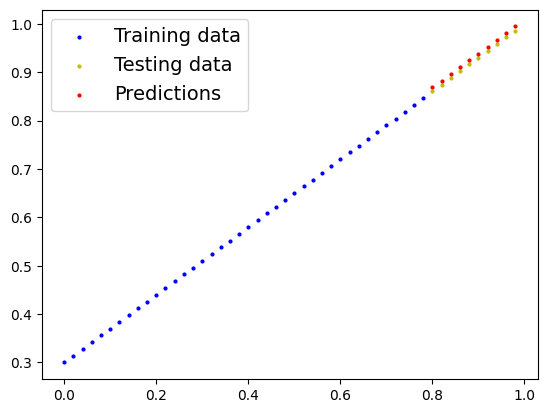

In [89]:
plot_predictions(predictions=y_preds_new)

In [95]:
import numpy as np

np.array(torch.tensor(loss_values).numpy())

array([0.07638873, 0.05069301, 0.04463796, 0.04098063, 0.03750344,
       0.03407188, 0.03063862, 0.02719982, 0.02376995, 0.020335  ,
       0.01689645, 0.01346802, 0.01003139, 0.00659453, 0.00316608,
       0.00893248, 0.00893248, 0.00893248, 0.00893248, 0.00893248],
      dtype=float32)

In [92]:
epoch_count[:5], loss_values[:5], test_loss_values[:5]

([0, 10, 20, 30, 40],
 [tensor(0.0764, grad_fn=<MeanBackward0>),
  tensor(0.0507, grad_fn=<MeanBackward0>),
  tensor(0.0446, grad_fn=<MeanBackward0>),
  tensor(0.0410, grad_fn=<MeanBackward0>),
  tensor(0.0375, grad_fn=<MeanBackward0>)],
 [tensor(0.1977),
  tensor(0.1365),
  tensor(0.1100),
  tensor(0.0970),
  tensor(0.0867)])

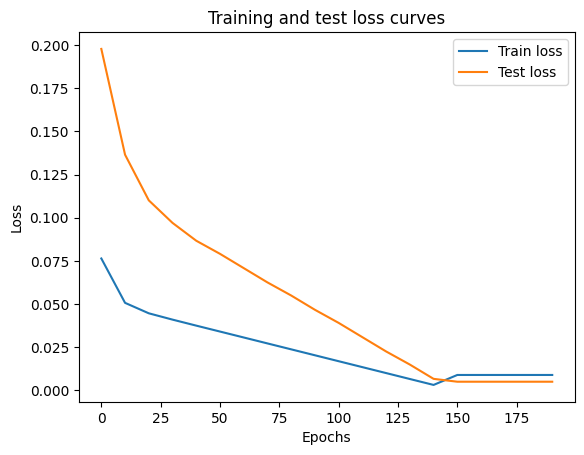

In [96]:
# plot loss curve
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Save / Load model

after training the model -> save it!

- `torch.save()` - save PyTorch object in python's pickle format
- `torch.load()` - load PyTorch object
- `torch.nn.Module.load_state_dict()` - allows to load a model's saved state dictionary


In [101]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [103]:
model_0._get_name()

'LinearRegressionModel'

In [99]:
from pathlib import Path

# 1. create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

In [105]:
# 2. create model save path
# .pth / .pt = pytorch object
MODEL_NAME = f"a03_{model_0._get_name()}.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
MODEL_SAVE_PATH

WindowsPath('models/a03_LinearRegressionModel.pth')

In [106]:
# 3. save the model state_dict
print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to models\a03_LinearRegressionModel.pth


In [110]:
# 4. load the model state_dict
loaded_model_0 = torch.load(MODEL_SAVE_PATH)
loaded_model_0

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [111]:
# since we saved only the state dict of a model, we will create a new instance of our model class
model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [112]:
model_1 = LinearRegressionModel()
model_1.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [113]:
# update new instance's parameters with the saved ones
model_1.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

<All keys matched successfully>

In [114]:
model_1.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [115]:
# make some predictions, when you make preds, you want it in evaluation mode
model_1.eval()
with torch.inference_mode():
    model_1_preds = model_1(X_test)

model_1_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [117]:
# make some (original) model preds
model_0.eval()
with torch.inference_mode():
    model_0_preds = model_0(X_test)

model_0_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [118]:
# compare loaded model preds with original model preds
model_0_preds, model_1_preds, model_0_preds == model_1_preds

(tensor([[0.8685],
         [0.8825],
         [0.8965],
         [0.9105],
         [0.9245],
         [0.9384],
         [0.9524],
         [0.9664],
         [0.9804],
         [0.9944]]),
 tensor([[0.8685],
         [0.8825],
         [0.8965],
         [0.9105],
         [0.9245],
         [0.9384],
         [0.9524],
         [0.9664],
         [0.9804],
         [0.9944]]),
 tensor([[True],
         [True],
         [True],
         [True],
         [True],
         [True],
         [True],
         [True],
         [True],
         [True]]))